In [ ]:
# Jupyter Config
%load_ext autoreload
%autoreload 2

# 1. Reading file paths

input: Folder with videofiles
output: csv

In [ ]:
input1 = [
    {
        "input_dir": r"C:\DB\AI",
        "output_csv": r".\1_videofiles\1_ai.csv"
    },
    {
        "input_dir": r"C:\DB\EVA-7K",
        "output_csv": r".\1_videofiles\1_eva.csv"
    },
    {
        "input_dir": r"C:\DB\VISION",
        "output_csv": r".\1_videofiles\1_vision.csv"
    }
]

import step1_videofiles as vf
for i in input1:
    vf.extract_video_paths(i['input_dir'], i['output_csv'])

# 2. Structuring data sets

input/output: csv

In [ ]:
import step2_datasets as ds

ds.process_selfmade_ai(
        r".\1_videofiles\1_ai.csv", 
        r".\2_datasets\2_ai.csv")

ds.process_vision(
        r".\1_videofiles\1_vision.csv", 
        r".\2_datasets\2_vision.csv")

ds.process_eva(
        r".\1_videofiles\1_eva.csv", 
        r".\2_datasets\2_eva.csv")

# 3. Analyze video structure

input: csv, videofiles
output: csv

In [ ]:
input3 = [
    {
        "input_csv": r".\2_datasets\2_ai.csv",
        "output_csv": r".\3_parse\3_ai.csv"
    },
    {
        "input_csv": r".\2_datasets\2_eva.csv",
        "output_csv": r".\3_parse\3_eva.csv"
    },
    {
        "input_csv": r".\2_datasets\2_vision.csv",
        "output_csv": r".\3_parse\3_vision.csv"
    }
]

import step3_parse as ps
for i in input3: 
    ps.process_dataset_with_pandas(i['input_csv'], i['output_csv'])

# 4. Calculate n-grams as a similarity digest

input/output: csv

In [ ]:
input4 = [
    {
        "input_csv": r".\3_parse\3_ai.csv",
        "output_csv": r".\4_ngrams\4_ai.csv"
    },
    {
        "input_csv": r".\3_parse\3_eva.csv",
        "output_csv": r".\4_ngrams\4_eva.csv"
    },
    {
        "input_csv": r".\3_parse\3_vision.csv",
        "output_csv": r".\4_ngrams\4_vision.csv"
    }
]

NGRAM_SIZES = [2, 3, 4]

import step4_ngrams as sg
for i in input4: 
    sg.process_ngrams(i['input_csv'], i['output_csv'], NGRAM_SIZES)

# 5. Divide in training and test (remaining files) data

input: any csv
output: two csv


In [ ]:
TRAIN_OUTPUT = r".\5_testtrainsplit\5_train.csv"
TEST_OUTPUT  = r".\5_testtrainsplit\5_test.csv"

import step5_testtrainsplit as tt
tt.split_dataset(
    input_files=[
        r".\4_ngrams\4_ai.csv",
        r".\4_ngrams\4_vision.csv",
        r".\4_ngrams\4_eva.csv",
    ],
    train_output=TRAIN_OUTPUT,
    test_output=TEST_OUTPUT,
    train_selector=["every_second", "first", "_0001"],
)

# 6. Generate source digest

input: training-csv
output: csv (attached)

In [ ]:
INPUT  = r".\5_testtrainsplit\5_train.csv"
OUTPUT = r".\6_sourcedigest\6_source_digests.csv"

import step6_sourcedigest as sd

## NATIVE

In [16]:
_devices = [
    "D01", "D02", "D03", "D04", "D05", "D06", "D08", "D09", "D10", "D11", "D12", "D13", "D14", "D15", "D16", "D17", "D18", "D19", "D20", 
    "D21", "D22", "D23", "D24", "D25", "D26", "D27", "D28", "D29", "D30", "D31", "D32", "D33", "D34", "D35"
]

input6_devices = [{"filters": {"id": d, "processing": "ORIGINAL"}} for d in _devices]

for i in input6_devices:
    sd.create_source_digest(INPUT, OUTPUT, filters=i["filters"], label=i.get("label"))

Source digest 'D01_ORIGINAL': 3 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'D02_ORIGINAL': 3 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'D03_ORIGINAL': 3 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'D04_ORIGINAL': 3 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'D05_ORIGINAL': 3 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'D06_ORIGINAL': 3 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'D08_ORIGINAL': 3 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'D09_ORIGINAL': 3 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'D10_ORIGINAL': 3 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'D11_ORIGINAL': 3 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'D12_ORIGINAL': 3 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source dig

In [ ]:
_models = [
    "iPad2", "iPadmini", "iPhone4", "iPhone4s", "iPhone5", "iPhone5c", "iPhone6", "iPhone6Plus",
    "Zenfone2Laser", "AscendG6", "Honor5", "P89", "P9", "P9lite", "D290", "Lumia640LTE",
    "A3000", "A3003", "GalaxyS3", "GalaxyS3Mini", "GalaxyS4Mini", "GalaxyS5",
    "GalaxyTab3", "GalaxyTabA", "GalaxyTrendPlus", "XperiaZ1Compact", "Ridge4G", "RedmiNote3",
]

input6_models = [{"filters": {"model": m, "processing": "ORIGINAL"}} for m in _models]

for i in input6_models:
    sd.create_source_digest(INPUT, OUTPUT, filters=i["filters"], label=i.get("label"))

In [ ]:
_brands = ["Apple", "Asus", "Huawei", "LG", "Microsoft", "OnePlus", "Samsung", "Sony", "Wiko", "Xiaomi"]

input6_brands = [{"filters": {"brand": b, "processing": "ORIGINAL"}} for b in _brands]

for i in input6_brands:
    sd.create_source_digest(INPUT, OUTPUT, filters=i["filters"], label=i.get("label"))

## Social Media

In [ ]:
_socials = [
    "WHATSAPP", "YOUTUBE", "FACEBOOK", "TIKTOK", "WEIBO"
]

input6_socials = [
    {"filters": {"processing": s, "tampering": "NATIVE"},}
    for s in _socials
]

for i in input6_socials:
    sd.create_source_digest(INPUT, OUTPUT, filters=i["filters"])

## AI

In [ ]:
_ais = [
    "OmniFlash", "Veo3.1", "Imagine0.9", "Imagine1.5", "KlingAIVideo2.6", "KlingAIVideo3.0", "Sora2", "Pika1.5", "Pika2.0", "Pika2.2", "Pika2.5"
]

input6_ais = [{"filters": {"model": a}} for a in _ais]

for i in input6_ais:
    sd.create_source_digest(INPUT, OUTPUT, filters=i["filters"], label=i.get("label"))

In [ ]:
_ais = [
    "SYNTHETIC", "DEEPFAKE"
]

input6_ais = [{"filters": {"content_type": a}} for a in _ais]

for i in input6_ais:
    sd.create_source_digest(INPUT, OUTPUT, filters=i["filters"], label=i.get("label"))

## Mixed

In [ ]:
input6_mixed = [
    {"filters": {"content_source": "DIGITAL_CAMERA", "processing": "ORIGINAL"}}, # Native Aufnahmen
    {"filters": {"db_name": "AI",}}, # AI Aufnahmen
]

for i in input6_mixed:
    sd.create_source_digest(INPUT, OUTPUT, filters=i["filters"], label=i.get("label"))

Source digest 'DIGITAL_CAMERA_ORIGINAL': 102 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'AI': 31 files aggregated -> .\6_sourcedigest\6_source_digests.csv


In [29]:
_tampered = [
    "native", "avidemux", "exiftool", "ffmpeg1", "ffmpeg2", "ffmpeg3", "ffmpeg4", "ffmpeg5", "kdenlive", "premiere"
]

input6_tampered = [{"filters": {"content_source": "DIGITAL_CAMERA", "tampering": t}} for t in _tampered]

for i in input6_tampered:
    sd.create_source_digest(INPUT, OUTPUT, filters=i["filters"], label=i.get("label"))

Source digest 'DIGITAL_CAMERA_native': 628 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'DIGITAL_CAMERA_avidemux': 316 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'DIGITAL_CAMERA_exiftool': 316 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'DIGITAL_CAMERA_ffmpeg1': 316 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'DIGITAL_CAMERA_ffmpeg2': 316 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'DIGITAL_CAMERA_ffmpeg3': 316 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'DIGITAL_CAMERA_ffmpeg4': 316 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'DIGITAL_CAMERA_ffmpeg5': 316 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'DIGITAL_CAMERA_kdenlive': 314 files aggregated -> .\6_sourcedigest\6_source_digests.csv
Source digest 'DIGITAL_CAMERA_premiere': 316 files aggregated -> .\6_sourcediges

# 7. Calculate similarity

input: source-digest-csv, test-csv
output: tversky

In [2]:
SOURCE_FILE = r".\6_sourcedigest\6_source_digests.csv"
TEST_FILE   = r".\5_testtrainsplit\5_test.csv"

import step7_similarity as sl

## NATIVE

In [18]:
OUTPUT_DIR = r".\7_similarity\devices"

_filters   = {"processing": "ORIGINAL", "content_source": "DIGITAL_CAMERA"}
_devices = [
    "D01", "D02", "D03", "D04", "D05", "D06", "D08", "D09", "D10", "D11", "D12", "D13", "D14", "D15", "D16", "D17", "D18", "D19", "D20", 
    "D21", "D22", "D23", "D24", "D25", "D26", "D27", "D28", "D29", "D30", "D31", "D32", "D33", "D34", "D35"
]

input7_devices = [{"source_label": f"{d}_ORIGINAL", "test_filters": _filters} for d in _devices]

for i in input7_devices:
    sl.compute_similarity(
        output_dir=OUTPUT_DIR,
        source_file=SOURCE_FILE,
        source_label=i["source_label"],
        test_file=TEST_FILE,
        test_filters=i["test_filters"],
    )

Finished! 525 rows -> .\7_similarity\devices\D01_ORIGINAL_vs_processing_ORIGINAL_content_source_DIGITAL_CAMERA.csv
Finished! 525 rows -> .\7_similarity\devices\D02_ORIGINAL_vs_processing_ORIGINAL_content_source_DIGITAL_CAMERA.csv
Finished! 525 rows -> .\7_similarity\devices\D03_ORIGINAL_vs_processing_ORIGINAL_content_source_DIGITAL_CAMERA.csv
Finished! 525 rows -> .\7_similarity\devices\D04_ORIGINAL_vs_processing_ORIGINAL_content_source_DIGITAL_CAMERA.csv
Finished! 525 rows -> .\7_similarity\devices\D05_ORIGINAL_vs_processing_ORIGINAL_content_source_DIGITAL_CAMERA.csv
Finished! 525 rows -> .\7_similarity\devices\D06_ORIGINAL_vs_processing_ORIGINAL_content_source_DIGITAL_CAMERA.csv
Finished! 525 rows -> .\7_similarity\devices\D08_ORIGINAL_vs_processing_ORIGINAL_content_source_DIGITAL_CAMERA.csv
Finished! 525 rows -> .\7_similarity\devices\D09_ORIGINAL_vs_processing_ORIGINAL_content_source_DIGITAL_CAMERA.csv
Finished! 525 rows -> .\7_similarity\devices\D10_ORIGINAL_vs_processing_ORIGINAL

In [ ]:
OUTPUT_DIR = r".\7_similarity\models"

_filters   = {"processing": "ORIGINAL", "content_source": "DIGITAL_CAMERA"}
_models   = [
    "iPad2", "iPadmini", "iPhone4", "iPhone4s", "iPhone5", "iPhone5c", "iPhone6", "iPhone6Plus",
    "Zenfone2Laser", "AscendG6", "Honor5", "P89", "P9", "P9lite", "D290", "Lumia640LTE",
    "A3000", "A3003", "GalaxyS3", "GalaxyS3Mini", "GalaxyS4Mini", "GalaxyS5",
    "GalaxyTab3", "GalaxyTabA", "GalaxyTrendPlus", "XperiaZ1Compact", "Ridge4G", "RedmiNote3",
]

input7_models = [{"source_label": f"{m}_ORIGINAL", "test_filters": _filters} for m in _models]

for i in input7_models:
    sl.compute_similarity(
        output_dir=OUTPUT_DIR,
        source_file=SOURCE_FILE,
        source_label=i["source_label"],
        test_file=TEST_FILE,
        test_filters=i["test_filters"],
    )

In [ ]:
OUTPUT_DIR = r".\7_similarity\brands"

_filters   = {"processing": "ORIGINAL", "content_source": "DIGITAL_CAMERA"}
_brands    = ["Apple", "Asus", "Huawei", "LG", "Microsoft", "OnePlus", "Samsung", "Sony", "Wiko", "Xiaomi"]

input7_brands = [{"source_label": f"{b}_original", "test_filters": _filters} for b in _brands]

for i in input7_brands:
    sl.compute_similarity(
        output_dir=OUTPUT_DIR,
        source_file=SOURCE_FILE,
        source_label=i["source_label"],
        test_file=TEST_FILE,
        test_filters=i["test_filters"],
    )

## Social Media

In [ ]:
OUTPUT_DIR = r".\7_similarity\sm"

_socials = [
    "WHATSAPP", "YOUTUBE", "FACEBOOK", "TIKTOK", "WEIBO"
]
_filters   = {"processing": _socials, "tampering": "NATIVE"} 

input7_socials = [{"source_label": f"{s}_native", "test_filters": _filters} for s in _socials]

for i in input7_socials:
    sl.compute_similarity(
        output_dir=OUTPUT_DIR,
        source_file=SOURCE_FILE,
        source_label=i["source_label"],
        test_file=TEST_FILE,
        test_filters=i["test_filters"],
    )

## AI

In [19]:
OUTPUT_DIR = r".\7_similarity\ai"

_ais = [
    "OmniFlash", "Veo3.1", "Imagine0.9", "Imagine1.5", "KlingAIVideo2.6", "KlingAIVideo3.0", "Sora2", "Pika1.5", "Pika2.0", "Pika2.2", "Pika2.5"
]
_filters   = {"db_name": "AI"} 

input7_ais = [{"source_label": a, "test_filters": _filters} for a in _ais]

for i in input7_ais:
    sl.compute_similarity(
        output_dir=OUTPUT_DIR,
        source_file=SOURCE_FILE,
        source_label=i["source_label"],
        test_file=TEST_FILE,
        test_filters=i["test_filters"],
    )

Error: source_label 'OmniFlash' not found in .\6_sourcedigest\6_source_digests.csv.
Error: source_label 'Veo3.1' not found in .\6_sourcedigest\6_source_digests.csv.
Error: source_label 'Imagine0.9' not found in .\6_sourcedigest\6_source_digests.csv.
Error: source_label 'Imagine1.5' not found in .\6_sourcedigest\6_source_digests.csv.
Error: source_label 'KlingAIVideo2.6' not found in .\6_sourcedigest\6_source_digests.csv.
Error: source_label 'KlingAIVideo3.0' not found in .\6_sourcedigest\6_source_digests.csv.
Error: source_label 'Sora2' not found in .\6_sourcedigest\6_source_digests.csv.
Error: source_label 'Pika1.5' not found in .\6_sourcedigest\6_source_digests.csv.
Error: source_label 'Pika2.0' not found in .\6_sourcedigest\6_source_digests.csv.
Error: source_label 'Pika2.2' not found in .\6_sourcedigest\6_source_digests.csv.
Error: source_label 'Pika2.5' not found in .\6_sourcedigest\6_source_digests.csv.


## Mixed

In [23]:
OUTPUT_DIR = r".\7_similarity\mixed"

_filters = {"processing": "ORIGINAL"}

input7_mixed = [
    {"source_label": "DIGITAL_CAMERA_ORIGINAL", "test_filters": _filters},
    {"source_label": "AI", "test_filters": _filters}
]

for i in input7_mixed:
    sl.compute_similarity(
        output_dir=OUTPUT_DIR,
        source_file=SOURCE_FILE,
        source_label=i["source_label"],
        test_file=TEST_FILE,
        test_filters=i["test_filters"],
    )

Finished! 555 rows -> .\7_similarity\mixed\DIGITAL_CAMERA_ORIGINAL_vs_processing_ORIGINAL.csv
Finished! 555 rows -> .\7_similarity\mixed\AI_vs_processing_ORIGINAL.csv


In [3]:
OUTPUT_DIR = r".\7_similarity\tampered"

_tampered = [
    "native", "avidemux", "exiftool", "ffmpeg1", "ffmpeg2", "ffmpeg3", "ffmpeg4", "ffmpeg5", "kdenlive", "premiere"
]


_filters   = {"content_source": "DIGITAL_CAMERA"} 

input7_ais = [{"source_label": f"DIGITAL_CAMERA_{t}", "test_filters": _filters} for t in _tampered]

for i in input7_ais:
    sl.compute_similarity(
        output_dir=OUTPUT_DIR,
        source_file=SOURCE_FILE,
        source_label=i["source_label"],
        test_file=TEST_FILE,
        test_filters=i["test_filters"],
    )

Finished! 4019 rows -> .\7_similarity\tampered\DIGITAL_CAMERA_native_vs_content_source_DIGITAL_CAMERA.csv
Finished! 4019 rows -> .\7_similarity\tampered\DIGITAL_CAMERA_avidemux_vs_content_source_DIGITAL_CAMERA.csv
Finished! 4019 rows -> .\7_similarity\tampered\DIGITAL_CAMERA_exiftool_vs_content_source_DIGITAL_CAMERA.csv
Finished! 4019 rows -> .\7_similarity\tampered\DIGITAL_CAMERA_ffmpeg1_vs_content_source_DIGITAL_CAMERA.csv
Finished! 4019 rows -> .\7_similarity\tampered\DIGITAL_CAMERA_ffmpeg2_vs_content_source_DIGITAL_CAMERA.csv
Finished! 4019 rows -> .\7_similarity\tampered\DIGITAL_CAMERA_ffmpeg3_vs_content_source_DIGITAL_CAMERA.csv
Finished! 4019 rows -> .\7_similarity\tampered\DIGITAL_CAMERA_ffmpeg4_vs_content_source_DIGITAL_CAMERA.csv
Finished! 4019 rows -> .\7_similarity\tampered\DIGITAL_CAMERA_ffmpeg5_vs_content_source_DIGITAL_CAMERA.csv
Finished! 4019 rows -> .\7_similarity\tampered\DIGITAL_CAMERA_kdenlive_vs_content_source_DIGITAL_CAMERA.csv
Finished! 4019 rows -> .\7_similari

# 8. Generate graphs

input: csv
output: png

## NATIVE

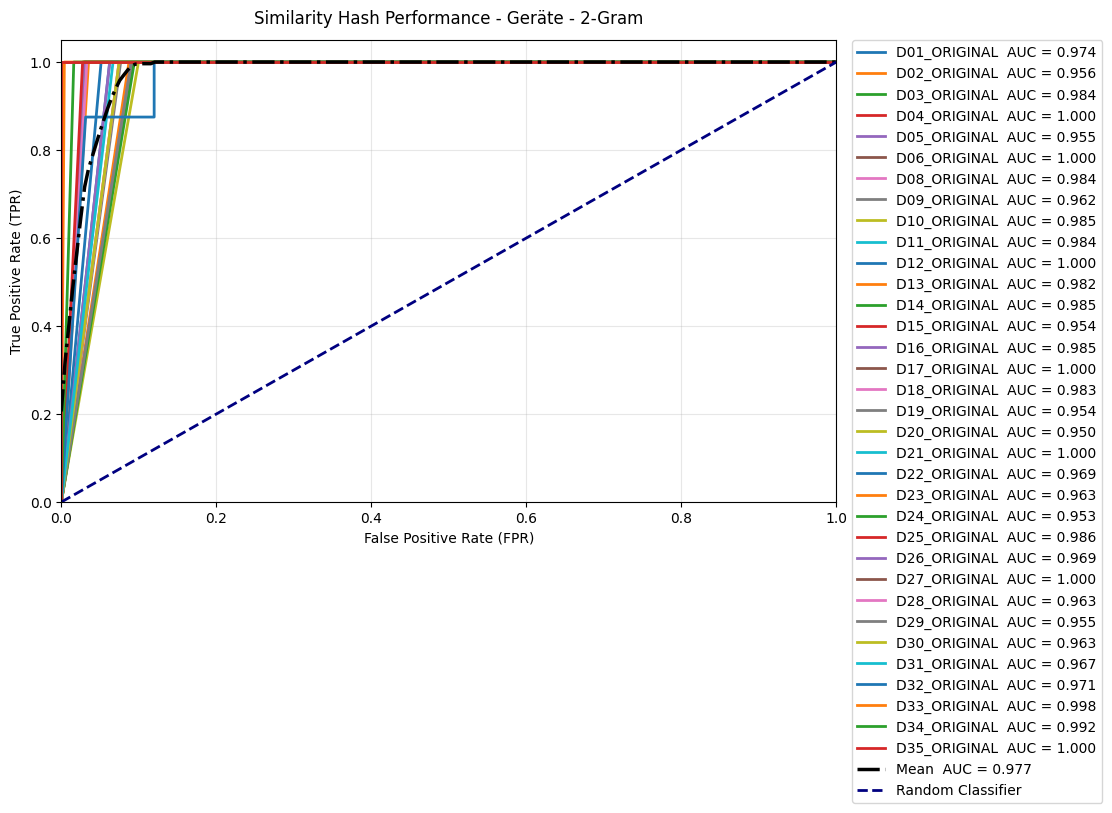

Saved -> .\8_curves\devices.png


In [21]:
NGRAM_SIZE = 2
TITLE=f"Similarity Hash Performance - Geräte - {NGRAM_SIZE}-Gram"
INPUT_CSVS = r".\7_similarity\devices"
OUTPUT_NAME="devices.png"

import step8_curves as cr
cr.plot_roc(
    input_csvs=INPUT_CSVS,
    ngram_size=NGRAM_SIZE,
    output_dir=r".\8_curves",
    output_name=OUTPUT_NAME,
    title=TITLE,
    show_mean=True,
    export_auc=True
)

In [ ]:
NGRAM_SIZE = 2
TITLE=f"Similarity Hash Performance - Modell - {NGRAM_SIZE}-Gram"
INPUT_CSVS = r".\7_similarity\models"
OUTPUT_NAME="models.png"

import step8_curves as cr
cr.plot_roc(
    input_csvs=INPUT_CSVS,
    ngram_size=NGRAM_SIZE,
    output_dir=r".\8_curves",
    output_name=OUTPUT_NAME,
    title=TITLE,
    show_mean=True,
    export_auc=True
)

In [ ]:
NGRAM_SIZE = 2
TITLE=f"Similarity Hash Performance - Hersteller - {NGRAM_SIZE}-Gram"
INPUT_CSVS = r".\7_similarity\brands"
OUTPUT_NAME="brands.png"

import step8_curves as cr
cr.plot_roc(
    input_csvs=INPUT_CSVS,
    ngram_size=NGRAM_SIZE,
    output_dir=r".\8_curves",
    output_name=OUTPUT_NAME,
    title=TITLE,
    show_mean=True,
    export_auc=True
)

## Social Media

In [ ]:
NGRAM_SIZE = 2
TITLE=f"Similarity Hash Performance - Social Media - {NGRAM_SIZE}-Gram"
INPUT_CSVS = r".\7_similarity\sm"
OUTPUT_NAME="sm.png"

import step8_curves as cr
cr.plot_roc(
    input_csvs=INPUT_CSVS,
    ngram_size=NGRAM_SIZE,
    output_dir=r".\8_curves",
    output_name=OUTPUT_NAME,
    title=TITLE,
    show_mean=True,
    export_auc=True
)

## AI

In [ ]:
NGRAM_SIZE = 2
TITLE=f"Similarity Hash Performance - KI-Generatoren - {NGRAM_SIZE}-Gram"
INPUT_CSVS = r".\7_similarity\ai"
OUTPUT_NAME="ai.png"

import step8_curves as cr
cr.plot_roc(
    input_csvs=INPUT_CSVS,
    ngram_size=NGRAM_SIZE,
    output_dir=r".\8_curves",
    output_name=OUTPUT_NAME,
    title=TITLE,
    show_mean=True,
    export_auc=True
)

In [ ]:
NGRAM_SIZE = 2
TITLE=f"Similarity Hash Performance - Deepfakes und synthetischen Videos - {NGRAM_SIZE}-Gram"
INPUT_CSVS = r".\7_similarity\dfsynth"
OUTPUT_NAME="dfsynth.png"

import step8_curves as cr
cr.plot_roc(
    input_csvs=INPUT_CSVS,
    ngram_size=NGRAM_SIZE,
    output_dir=r".\8_curves",
    output_name=OUTPUT_NAME,
    title=TITLE,
    show_mean=True,
    export_auc=True
)

## Mixed

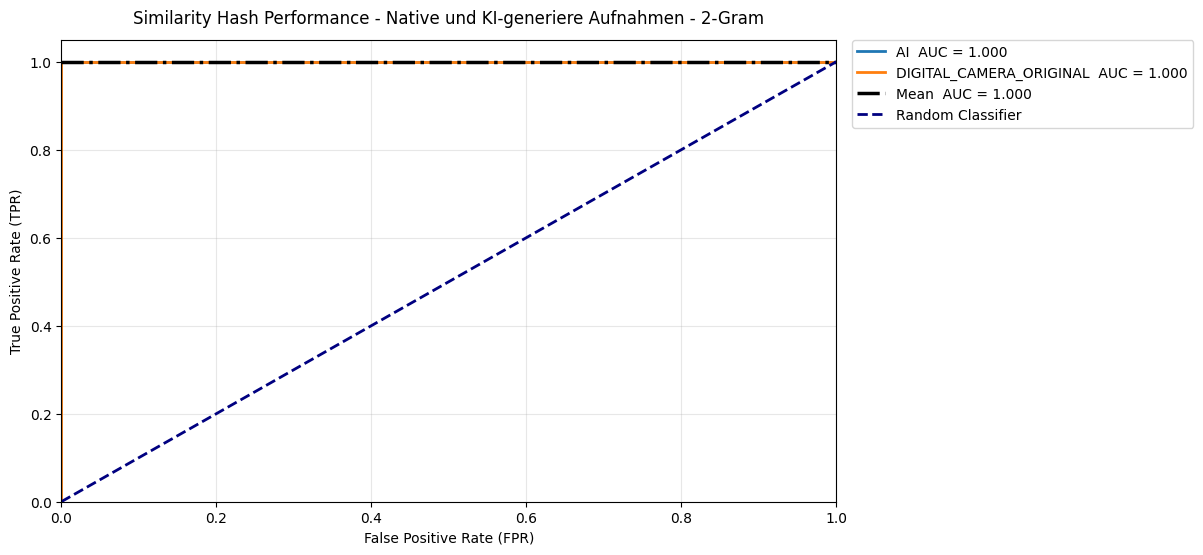

Saved -> .\8_curves\natki.png


In [32]:
NGRAM_SIZE = 2
TITLE=f"Similarity Hash Performance - Native und KI-generiere Aufnahmen - {NGRAM_SIZE}-Gram"
INPUT_CSVS = [
    r".\7_similarity\mixed\AI_vs_processing_ORIGINAL.csv",
    r".\7_similarity\mixed\DIGITAL_CAMERA_ORIGINAL_vs_processing_ORIGINAL.csv",
]

OUTPUT_NAME="natki.png"

import step8_curves as cr
cr.plot_roc(
    input_csvs=INPUT_CSVS,
    ngram_size=NGRAM_SIZE,
    output_dir=r".\8_curves",
    output_name=OUTPUT_NAME,
    title=TITLE,
    show_mean=True,
    export_auc=True
)

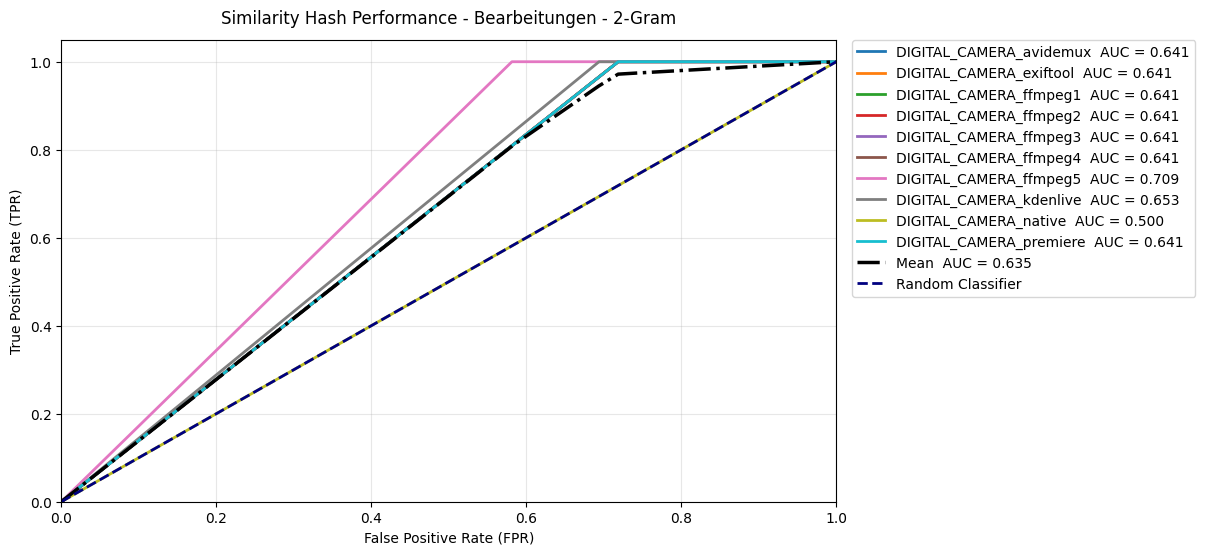

Saved -> .\8_curves\tampered.png


In [4]:
NGRAM_SIZE = 2
TITLE=f"Similarity Hash Performance - Bearbeitungen - {NGRAM_SIZE}-Gram"
INPUT_CSVS = r".\7_similarity\tampered"

OUTPUT_NAME="tampered.png"

import step8_curves as cr
cr.plot_roc(
    input_csvs=INPUT_CSVS,
    ngram_size=NGRAM_SIZE,
    output_dir=r".\8_curves",
    output_name=OUTPUT_NAME,
    title=TITLE,
    show_mean=True,
    export_auc=True
)